In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in the data
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words), len(set(words))

(32033, 29494)

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
# for w in words[:5]:
#     print(w)
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [7]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g) # character embedding matrix

In [8]:
C[torch.tensor([5,6,7,7,7])]

tensor([[-0.4713,  0.7868],
        [-0.3284, -0.4330],
        [ 1.3729,  2.9334],
        [ 1.3729,  2.9334],
        [ 1.3729,  2.9334]])

In [9]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-0.4713,  0.7868])

In [10]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [11]:
# the hidden layer
W1 = torch.randn((6, 100), generator=g) # 6 = block_size * embedding_size; 100 = hidden layer size, the hyperparameter we can tune
b1 = torch.randn(100, generator=g) # bias is a vector of length equal to the number of neurons in the layer

In [12]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1)
torch.unbind(emb, 1)
torch.cat(torch.unbind(emb, 1), dim=1)

tensor([[ 1.5674, -0.2373,  1.5674, -0.2373,  1.5674, -0.2373],
        [ 1.5674, -0.2373,  1.5674, -0.2373, -0.4713,  0.7868],
        [ 1.5674, -0.2373, -0.4713,  0.7868,  2.4448, -0.6701],
        ...,
        [ 0.2569,  0.2130,  0.2569,  0.2130, -1.4904, -0.2838],
        [ 0.2569,  0.2130, -1.4904, -0.2838,  0.2569,  0.2130],
        [-1.4904, -0.2838,  0.2569,  0.2130, -0.5132,  0.2961]])

In [13]:
a = torch.arange(18)
a.view(3, 6)
a.view(3, 2, 3)
a.storage()

/tmp/ipykernel_2608894/2769440496.py:4: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [14]:
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)

In [15]:
h, h.shape

(tensor([[-0.9348,  1.0000,  0.9258,  ...,  0.9786, -0.1926,  0.9515],
         [ 0.2797,  0.9997,  0.7675,  ...,  0.9929,  0.9992,  0.9981],
         [-0.9960,  1.0000, -0.8694,  ..., -0.5159, -1.0000, -0.0069],
         ...,
         [-0.4849,  0.9972, -0.6418,  ..., -0.9641,  0.9996,  0.9873],
         [-0.9318,  0.9926, -0.9841,  ..., -0.8989, -0.9938,  0.5930],
         [-0.9736,  0.3844, -0.8744,  ..., -0.5093,  0.9998, -0.9975]]),
 torch.Size([228146, 100]))

In [16]:
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

In [17]:
logits = h @ W2 + b2

In [18]:
logits.shape

torch.Size([228146, 27])

In [19]:
logits.max(1)

torch.return_types.max(
values=tensor([21.6638, 26.2643, 25.9028,  ..., 20.5985, 13.8653, 12.8429]),
indices=tensor([10, 10,  9,  ..., 10, 11, 17]))

In [20]:
# softmax to get probabilities
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
probs.shape

torch.Size([228146, 27])

In [21]:
loss = -probs[torch.arange(len(Y)), Y].log().mean()
loss

tensor(19.5052)

In [22]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g) # character embedding matrix
W1 = torch.randn((6, 100), generator=g) # 6 = block_size * embedding_size; 100 = hidden layer size, the hyperparameter we can tune
b1 = torch.randn(100, generator=g) # bias is a vector of length equal to the number of neurons in the layer
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)   
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [23]:
sum(p.nelement() for p in parameters)   

3481

In [24]:
for _ in range(10):
    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 # learning rate
    for p in parameters:
        p.data += -lr * p.grad

print(loss.item())

11.05185604095459


In [25]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [26]:
lri = []
lossi = []

for i in range(10000):
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,)) # select 32 random rows from X and Y to create a minibatch

    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    # print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 10**-2 # learning rate
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    # lossi.append(loss.item())

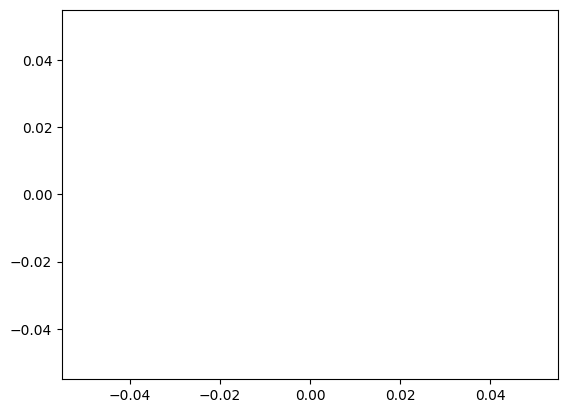

In [27]:
# track stats and plot, to find a decent learning rate
plt.plot(lri, lossi)

In [28]:
emb = C[X]
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.5747, grad_fn=<NllLossBackward0>)

learning rate decay, lower the learning rate around the end of the training process.

split the data set into three
training split, dev/validation split, test split
80%, 10%, 10%

- training split to train the model
- validation split to adjust the hyperparameters
- test split to evaluate the performand of the model in the end, only test very few times, to prevent overfitting.

In [88]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)   


cuda


In [89]:
# build the dataset

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    # for w in words[:5]:
    #     print(w)
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    print(X.shape, X.dtype, Y.shape, Y.dtype)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182484, 3]) torch.int64 torch.Size([182484]) torch.int64
torch.Size([22869, 3]) torch.int64 torch.Size([22869]) torch.int64
torch.Size([22793, 3]) torch.int64 torch.Size([22793]) torch.int64


In [117]:
g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((27, 10), generator=g, device=device) # character embedding matrix
W1 = torch.randn((30, 200), generator=g, device=device) # 6 = block_size * embedding_size; 100 = hidden layer size, the hyperparameter we can tune
b1 = torch.randn(200, generator=g, device=device) # bias is a vector of length equal to the number of neurons in the layer
W2 = torch.randn((200, 27), generator=g, device=device)
b2 = torch.randn(27, generator=g, device=device)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [118]:
lri = []
lossi = []
stepi = []

In [121]:

for i in range(20000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,), generator=g, device=device) # select 32 random rows from X and Y to create a minibatch

    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 # learning rate
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

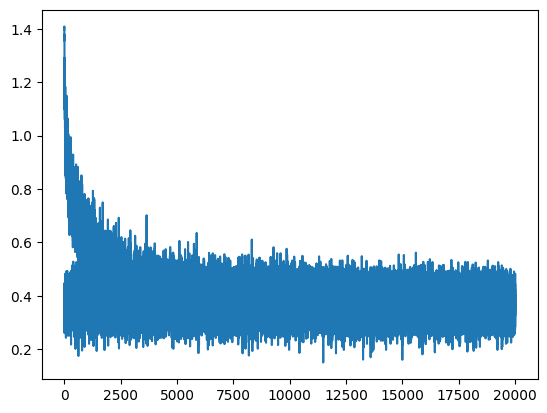

In [103]:
plt.plot(stepi, lossi)

In [104]:
print(loss.item())

2.7649998664855957


In [122]:
emb = C[Xtr]
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.3110, device='cuda:0', grad_fn=<NllLossBackward0>)

In [123]:
emb = C[Xdev]
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3402, device='cuda:0', grad_fn=<NllLossBackward0>)

loss of training set and validation set is fairly equal, means under fitting. The NN is too small.


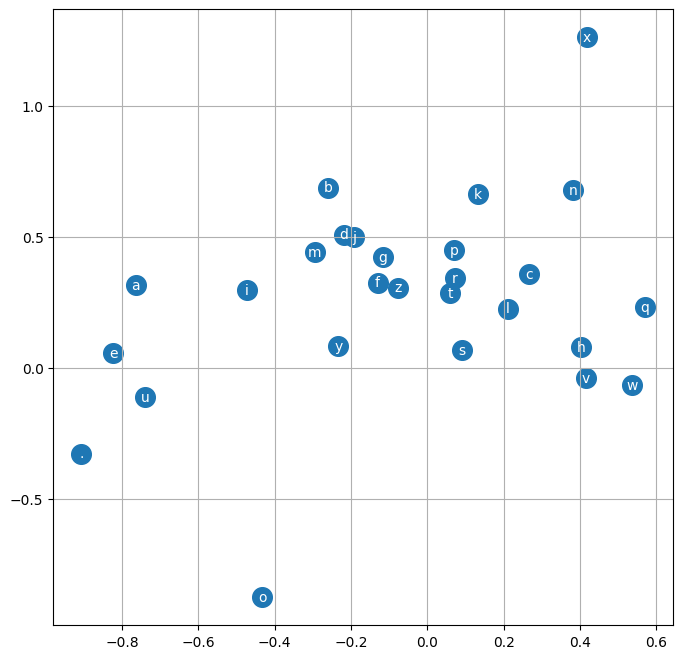

In [126]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].detach().cpu().numpy(), C[:,1].detach().cpu().numpy(), s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

changes of the hyperparameters:
- embedding space dimension
- dimension of the hidden layers
- minibatch size
- learning rate

In [127]:
# sample from the model
g = torch.Generator(device=device).manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initial context is always the beginning of a word
    while True:
        x = torch.tensor([context], device=device)
        emb = C[x]
        h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))    
    

brextsn.
ten.
mariellijahna.
brigen.
jeidi.
keurie.
emi.
cargin.
derophelsin.
met.
tarelloni.
arsh.
tattiena.
jidy.
avrah.
aan.
cerlen.
cerince.
jeri.
thi.
